# Summer Training Practical Test
**Topics:** Python Basics · Data Cleaning · Visualization · Linear Regression · Logistic Regression · Decision Trees · Random Forest

---

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris, load_diabetes, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Python Basics Warm-Up

In [2]:
# List comprehensions, lambda, map/filter
nums = list(range(1, 21))
squares = [x**2 for x in nums]
evens = list(filter(lambda x: x % 2 == 0, nums))
doubled = list(map(lambda x: x * 2, evens))

print('Squares:', squares[:5], '...')
print('Evens:', evens)
print('Doubled evens:', doubled)

# Dictionary operations
scores = {'Alice': 92, 'Bob': 78, 'Carol': 85, 'Dave': 91}
top = {k: v for k, v in scores.items() if v >= 85}
print('\nTop scorers:', top)
print('Average score:', sum(scores.values()) / len(scores))

Squares: [1, 4, 9, 16, 25] ...
Evens: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Doubled evens: [4, 8, 12, 16, 20, 24, 28, 32, 36, 40]

Top scorers: {'Alice': 92, 'Carol': 85, 'Dave': 91}
Average score: 86.5


In [3]:
# NumPy essentials
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print('Shape:', arr.shape)
print('Mean per column:', arr.mean(axis=0))
print('Transpose:\n', arr.T)

# Broadcasting
normalized = (arr - arr.mean()) / arr.std()
print('\nNormalized (mean~0, std~1):', normalized.round(2))

Shape: (3, 3)
Mean per column: [4. 5. 6.]
Transpose:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]

Normalized (mean~0, std~1): [[-1.55 -1.16 -0.77]
 [-0.39  0.    0.39]
 [ 0.77  1.16  1.55]]


---
## 2. Data Cleaning — Titanic-style Synthetic Dataset

In [4]:
# Create a messy synthetic dataset
np.random.seed(0)
n = 200
raw = pd.DataFrame({
    'Age':     np.where(np.random.rand(n) < 0.1, np.nan, np.random.randint(5, 80, n).astype(float)),
    'Salary':  np.where(np.random.rand(n) < 0.05, np.nan, np.random.randint(20000, 120000, n).astype(float)),
    'Gender':  np.random.choice(['Male', 'Female', None, 'male', 'female'], n),
    'Department': np.random.choice(['HR', 'IT', 'Finance', 'IT', None], n),
    'YearsExp': np.random.randint(0, 30, n),
    'Promoted': np.random.choice([0, 1], n)
})
print('Shape:', raw.shape)
raw.head()

Shape: (200, 6)


,Age,Salary,Gender,Department,YearsExp,Promoted
0,75.0,119128.0,female,NaN,23,1
1,76.0,82782.0,Male,IT,18,1
2,23.0,108624.0,female,IT,18,0
3,48.0,41649.0,male,NaN,22,0
4,54.0,79253.0,Female,HR,21,0


Missing values per column:
Age           19
Salary        12
Gender        34
Department    43
YearsExp       0
Promoted       0
dtype: int64


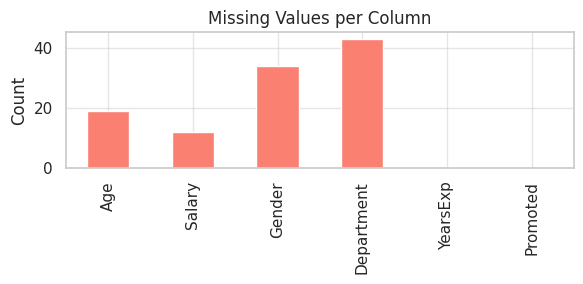

In [5]:
# Check missing values
print('Missing values per column:')
print(raw.isnull().sum())

fig, ax = plt.subplots(figsize=(6, 3))
raw.isnull().sum().plot(kind='bar', ax=ax, color='salmon')
ax.set_title('Missing Values per Column')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
df_clean = raw.copy()

# Fix inconsistent gender labels
df_clean['Gender'] = df_clean['Gender'].str.capitalize()

# Fill missing numerical with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Salary'].fillna(df_clean['Salary'].median(), inplace=True)

# Fill missing categorical with mode
df_clean['Gender'].fillna(df_clean['Gender'].mode()[0], inplace=True)
df_clean['Department'].fillna(df_clean['Department'].mode()[0], inplace=True)

print('Missing after cleaning:', df_clean.isnull().sum().sum())
df_clean.describe()

Missing after cleaning: 108


/tmp/ipykernel_137166/714452092.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_137166/714452092.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace metho

,Age,Salary,YearsExp,Promoted
count,181.000000,188.000000,200.000000,200.000000
mean,43.353591,70009.271277,15.665000,0.580000
std,22.188757,26789.103330,8.515595,0.494797
min,5.000000,21291.000000,0.000000,0.000000
25%,25.000000,46974.250000,8.750000,0.000000
50%,44.000000,70366.000000,16.000000,1.000000
75%,62.000000,91304.000000,23.000000,1.000000
max,79.000000,119415.000000,29.000000,1.000000


---
## 3. Exploratory Data Analysis & Visualisation

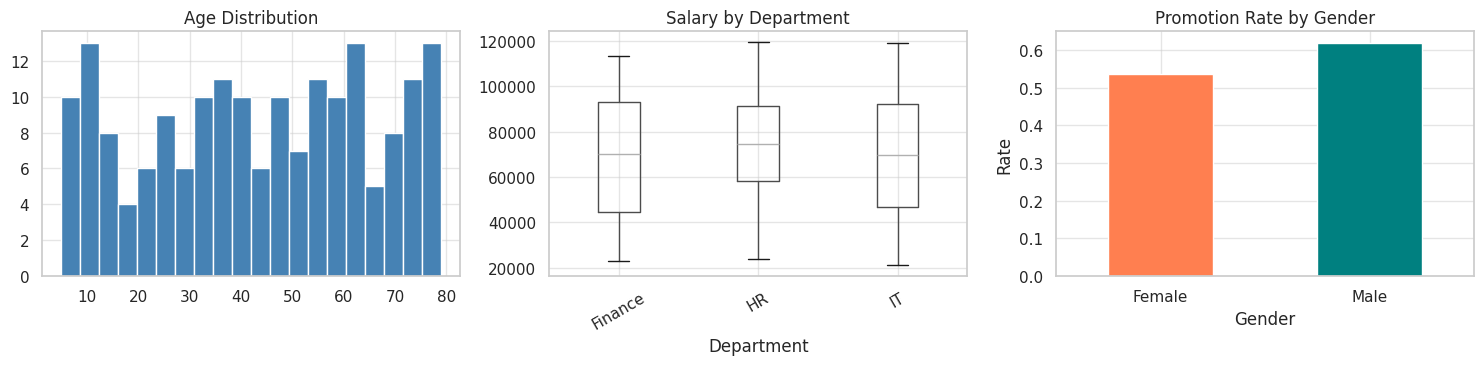

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df_clean['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')

# Salary by Department
df_clean.boxplot(column='Salary', by='Department', ax=axes[1])
axes[1].set_title('Salary by Department')
plt.sca(axes[1])
plt.xticks(rotation=30)

# Promotion rate by Gender
promo = df_clean.groupby('Gender')['Promoted'].mean()
promo.plot(kind='bar', ax=axes[2], color=['coral', 'teal'])
axes[2].set_title('Promotion Rate by Gender')
axes[2].set_ylabel('Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.show()

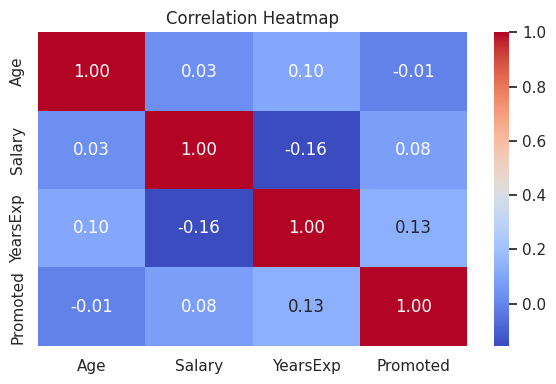

In [8]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(6, 4))
sns.heatmap(df_clean.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## 4. Linear Regression — California Housing Dataset

In [9]:
housing = fetch_california_housing(as_frame=True)
df_house = housing.frame
print('Shape:', df_house.shape)
df_house.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Correlation with target:
 MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


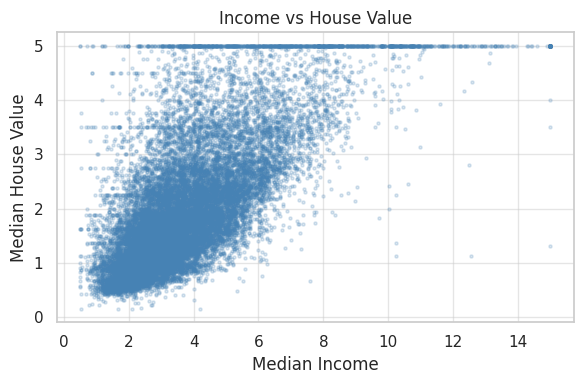

In [10]:
# Quick EDA — target vs most correlated feature
corr = df_house.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print('Correlation with target:\n', corr)

plt.figure(figsize=(6, 4))
plt.scatter(df_house['MedInc'], df_house['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Income vs House Value')
plt.tight_layout()
plt.show()

R² Score : 0.5758
RMSE     : 0.7456


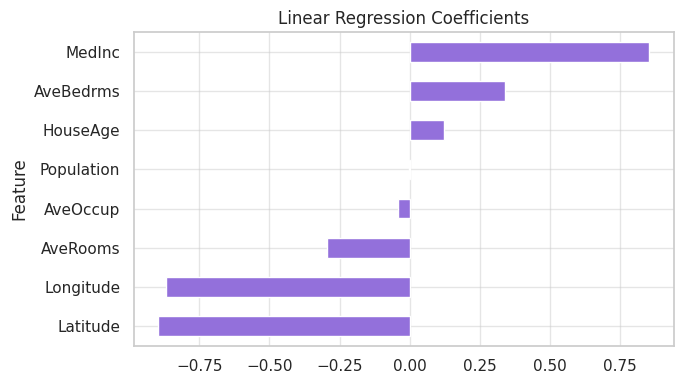

In [11]:
X = df_house.drop('MedHouseVal', axis=1)
y = df_house['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values('Coefficient')
coef_df.set_index('Feature')['Coefficient'].plot(kind='barh', figsize=(7, 4), color='mediumpurple')
plt.title('Linear Regression Coefficients')
plt.tight_layout()
plt.show()

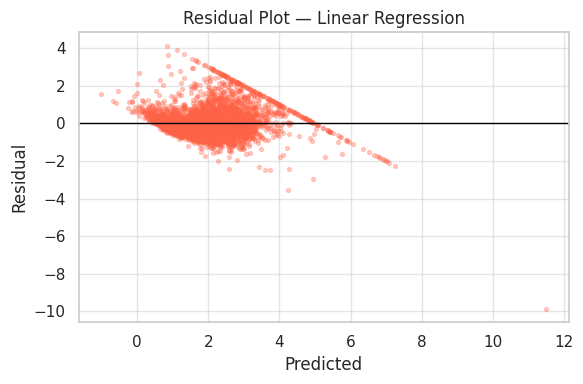

In [12]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.3, s=8, color='tomato')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual Plot — Linear Regression')
plt.tight_layout()
plt.show()

---
## 5. Logistic Regression — Breast Cancer Dataset

In [13]:
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame
print('Classes:', cancer.target_names)
print('Class distribution:\n', df_cancer['target'].value_counts())
df_cancer.head()

Classes: ['malignant' 'benign']
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


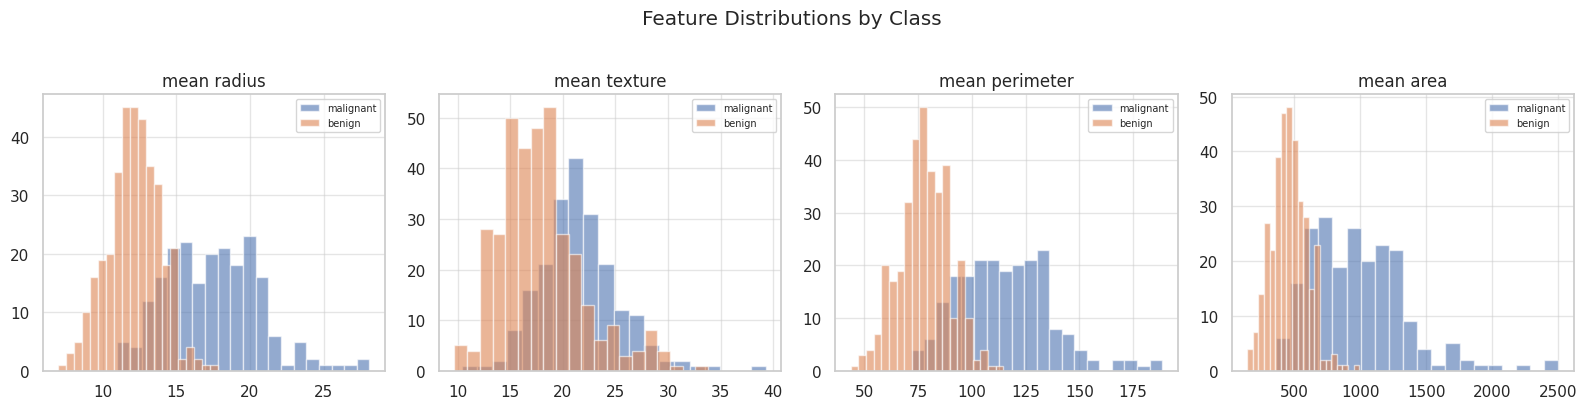

In [14]:
# Feature distributions by class
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    for cls, label in zip([0, 1], cancer.target_names):
        ax.hist(df_cancer[df_cancer['target'] == cls][feat], bins=20, alpha=0.6, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=7)
plt.suptitle('Feature Distributions by Class', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
y_pred = log_reg.predict(X_test_s)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



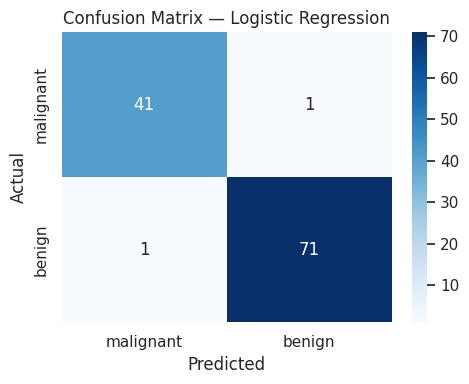

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

---
## 6. Decision Tree — Iris Dataset (Multi-class)

In [17]:
iris = load_iris(as_frame=True)
df_iris = iris.frame
print('Classes:', iris.target_names)
df_iris.head()

Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


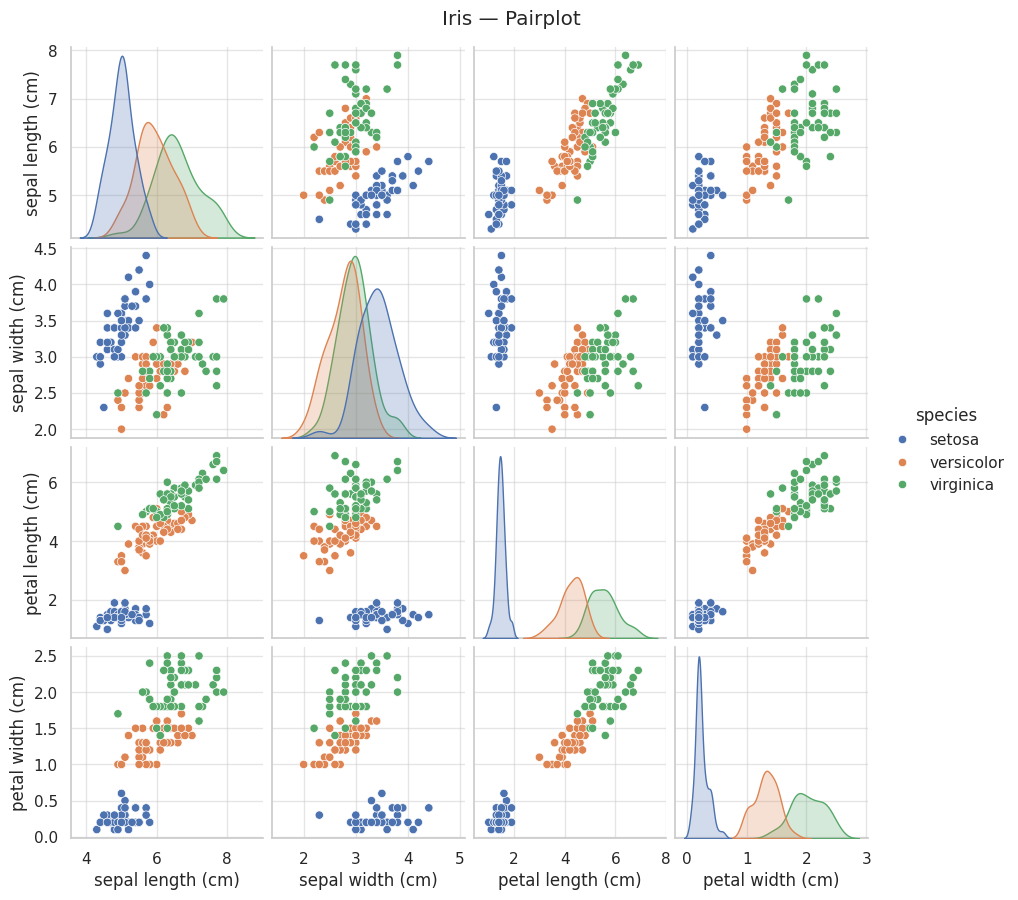

In [18]:
# Pairplot
df_plot = df_iris.copy()
df_plot['species'] = df_plot['target'].map({i: n for i, n in enumerate(iris.target_names)})
sns.pairplot(df_plot.drop('target', axis=1), hue='species', height=2.2, diag_kind='kde')
plt.suptitle('Iris — Pairplot', y=1.02)
plt.show()

In [19]:
X = df_iris.drop('target', axis=1)
y = df_iris['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



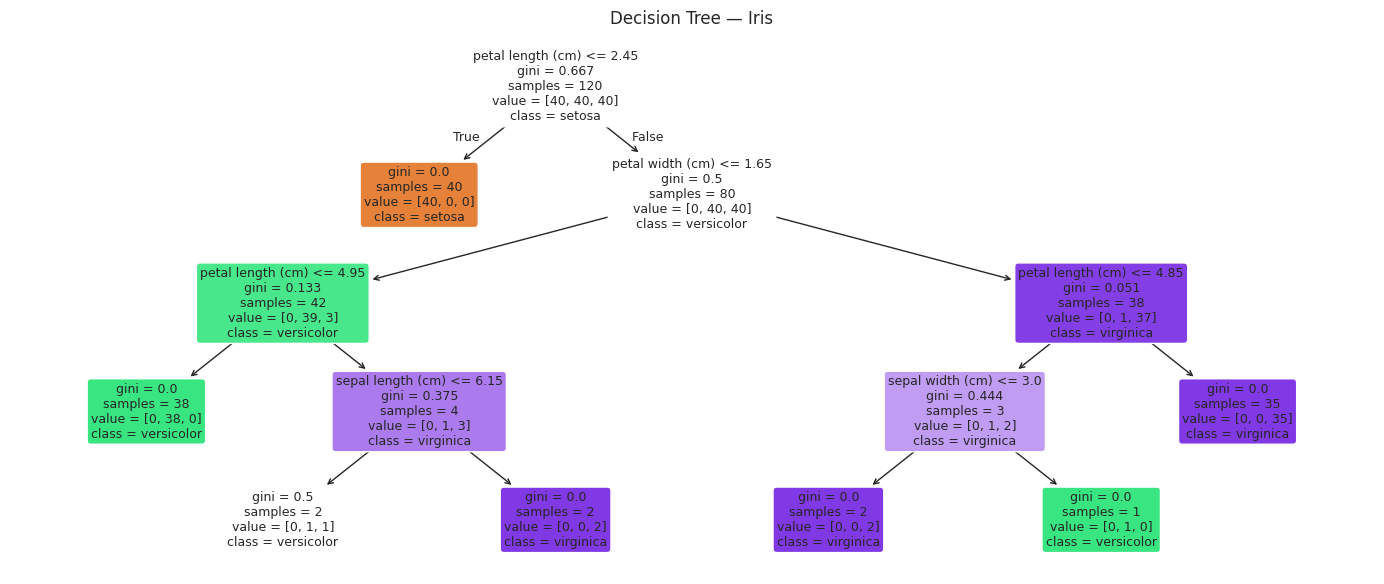

In [20]:
plt.figure(figsize=(14, 6))
plot_tree(dt, feature_names=X.columns, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — Iris')
plt.tight_layout()
plt.show()

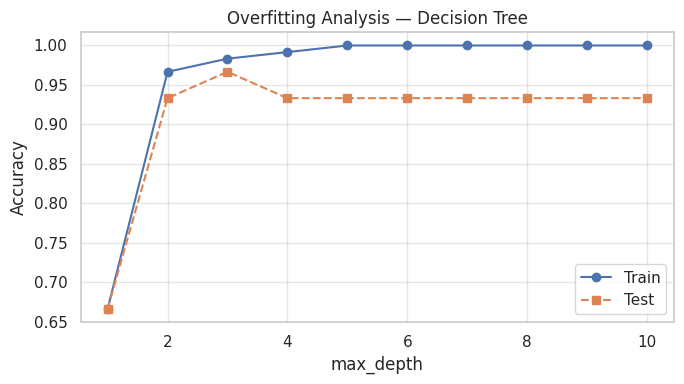

In [21]:
# Effect of max_depth on accuracy
depths = range(1, 11)
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_acc, 'o-', label='Train')
plt.plot(depths, test_acc, 's--', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis — Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Random Forest — Classification (Breast Cancer) & Regression (Diabetes)

In [22]:
# --- 7A. Random Forest Classifier on Breast Cancer ---
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Random Forest Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



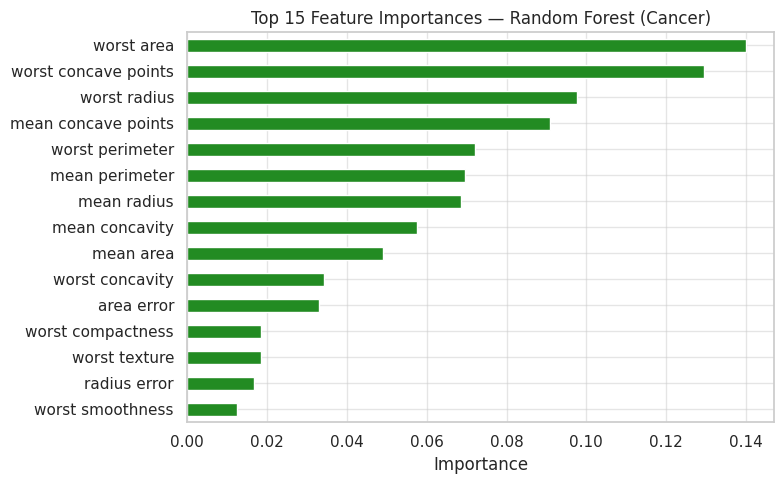

In [23]:
# Feature importance
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
feat_imp.plot(kind='barh', figsize=(8, 5), color='forestgreen')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest (Cancer)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [24]:
# --- 7B. Random Forest Regressor on Diabetes Dataset ---
diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame
print('Shape:', df_diab.shape)
df_diab.head()

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


R² Score : 0.4428
RMSE     : 54.3324


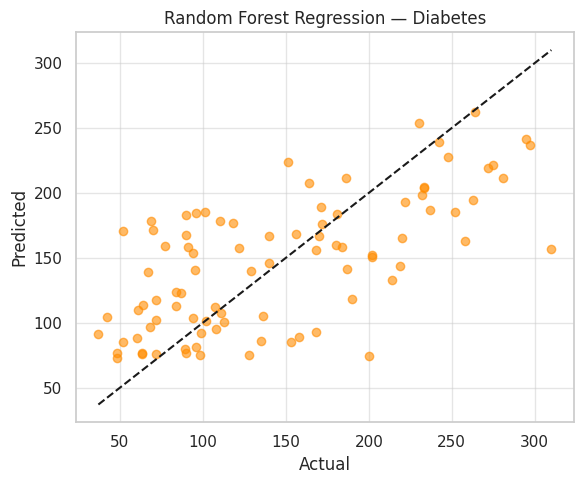

In [25]:
X = df_diab.drop('target', axis=1)
y = df_diab['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regression — Diabetes')
plt.tight_layout()
plt.show()

---
## 8. Model Comparison — All Four Algorithms Side-by-Side

In [26]:
# Compare classifiers on Breast Cancer using cross-validation
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_s, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Logistic Regression        mean=0.9807  std=0.0065
Decision Tree              mean=0.9191  std=0.0180
Random Forest              mean=0.9561  std=0.0228


/tmp/ipykernel_137166/4277775519.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys(), patch_artist=True,


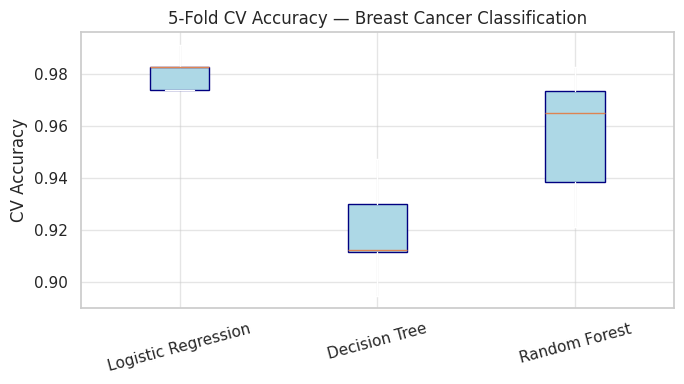

In [27]:
plt.figure(figsize=(7, 4))
plt.boxplot(results.values(), labels=results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'))
plt.ylabel('CV Accuracy')
plt.title('5-Fold CV Accuracy — Breast Cancer Classification')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## 9. Mixed Dataset Scenario — Custom Synthetic Data with Noise
> Scenario: Predict whether a student passes based on study hours, sleep, previous score, and extracurricular activities.

In [28]:
np.random.seed(7)
n = 500
study_hours   = np.random.uniform(1, 10, n)
sleep_hours   = np.random.uniform(4, 9, n)
prev_score    = np.random.uniform(30, 100, n)
extracurricular = np.random.choice([0, 1], n)  # 0=No, 1=Yes

# Rule: pass if weighted score > threshold + noise
score = 0.4 * study_hours + 0.2 * sleep_hours + 0.01 * prev_score + 0.5 * extracurricular
passed = (score + np.random.normal(0, 0.5, n) > 3.5).astype(int)

df_student = pd.DataFrame({
    'StudyHours': study_hours,
    'SleepHours': sleep_hours,
    'PrevScore':  prev_score,
    'Extracurricular': extracurricular,
    'Passed': passed
})
print('Class distribution:', df_student['Passed'].value_counts().to_dict())
df_student.describe()

Class distribution: {1: 360, 0: 140}


,StudyHours,SleepHours,PrevScore,Extracurricular,Passed
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.518273,6.460821,64.152480,0.514000,0.720000
std,2.623648,1.432013,20.767869,0.500305,0.449449
min,1.012842,4.000925,30.429423,0.000000,0.000000
25%,3.257918,5.233870,45.428755,0.000000,0.000000
50%,5.405429,6.399562,65.143874,1.000000,1.000000
75%,7.880193,7.713488,82.926630,1.000000,1.000000
max,9.992875,8.998665,99.837278,1.000000,1.000000


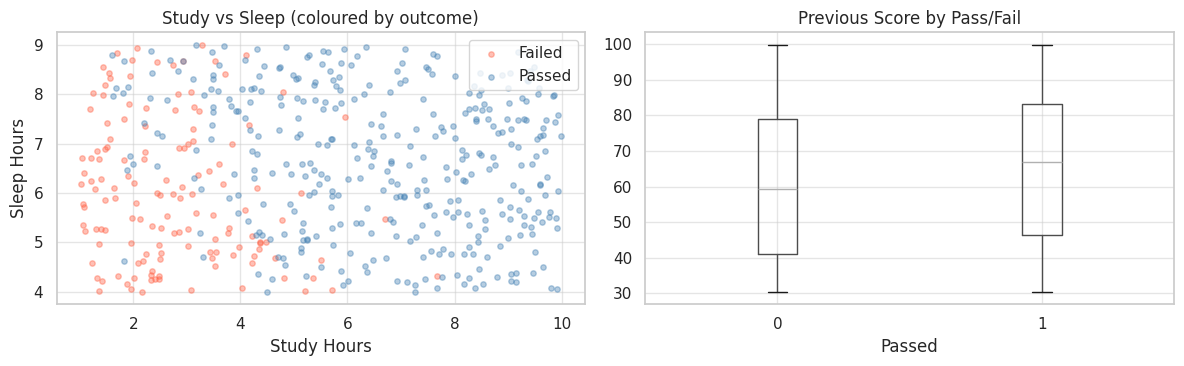

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, lbl, col in zip([0,1], ['Failed','Passed'], ['tomato','steelblue']):
    sub = df_student[df_student['Passed'] == cls]
    axes[0].scatter(sub['StudyHours'], sub['SleepHours'], alpha=0.4, s=15, label=lbl, color=col)
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Sleep Hours')
axes[0].set_title('Study vs Sleep (coloured by outcome)')
axes[0].legend()

df_student.boxplot(column='PrevScore', by='Passed', ax=axes[1])
axes[1].set_title('Previous Score by Pass/Fail')
axes[1].set_xlabel('Passed')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [30]:
X = df_student.drop('Passed', axis=1)
y = df_student['Passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

for name, model in [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
]:
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f'{name:25s}  Accuracy: {acc:.4f}')

Logistic Regression        Accuracy: 0.9300
Decision Tree              Accuracy: 0.8500
Random Forest              Accuracy: 0.8800


---
## 10. Summary

| Section | Dataset | Algorithm | Task |
|---------|---------|-----------|------|
| 4 | California Housing | Linear Regression | Regression |
| 5 | Breast Cancer | Logistic Regression | Binary Classification |
| 6 | Iris | Decision Tree | Multi-class Classification |
| 7A | Breast Cancer | Random Forest | Binary Classification |
| 7B | Diabetes | Random Forest | Regression |
| 8 | Breast Cancer | All (CV comparison) | Benchmarking |
| 9 | Synthetic Student | All | Mixed features |

**Key takeaways:**
- Always check for missing values and inconsistent labels before modelling.
- Scale features for Logistic Regression; tree-based models don't need it.
- Use cross-validation to get reliable accuracy estimates.
- Random Forest reduces overfitting compared to a single Decision Tree.
- Feature importance from Random Forest helps interpret the model.
